In [9]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as si
import random as rd
from IPython.display import HTML
from matplotlib.animation import FuncAnimation

Para el péndulo simple escalado las ecuaciones son:
$$
\dot \theta = v_{\theta}
$$
$$
\dot v_{\theta} = - \sin(\theta)
$$
con variables $(\theta, v_{\theta})$ y la energía escalada:
$$
\varepsilon = \frac{\dot \theta ^2}{2} + (1-\cos(\theta))
$$

In [2]:
def pendulo(t,th_vth):
    return np.array([th_vth[1] , -np.sin(th_vth[0]) ])

def E_pendulo(th_vth):
    return 0.5*th_vth[1]**2 + (1-np.cos(th_vth[0]))

def th2xy(th_vth):
    x = sin(th_vth[0])
    y = -cos(th_vth[0])
    return  np.array([x,y])

In [3]:
ci = [0.1,0]
titf = (0,100)
sol_pendulo = si.solve_ivp(pendulo,titf,ci,rtol=1e-8,atol=1e-10,dense_output=True)

0.0049958347219741794 0.004995833184506592 1.537467587270358e-09


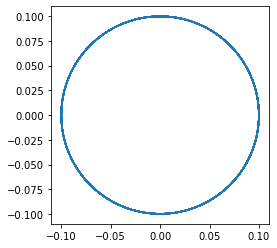

In [4]:
t = np.linspace(titf[0],titf[-1],1000)
th_vth = sol_pendulo.sol(t)
E = E_pendulo(th_vth)
print(E[0] , E[-1] , abs(E[0] - E[-1]) )
plt.plot(th_vth[0],th_vth[1])
plt.gca().set_aspect('equal')
plt.show()

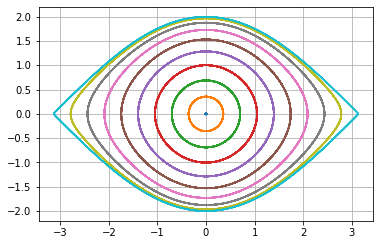

In [5]:
titf = (0,100)
t = np.linspace(titf[0],titf[-1],1000)
N_tray = 10
th0 = np.linspace(1e-2,np.pi-1e-2,N_tray)
for i in range(N_tray):
    ci = [th0[i],0]
    sol_pendulo = si.solve_ivp(pendulo,titf,ci,rtol=1e-8,atol=1e-10,dense_output=True)
    th_vth = sol_pendulo.sol(t)
    plt.plot(th_vth[0],th_vth[1])
plt.gca().set_aspect('equal')
plt.grid()
plt.show()

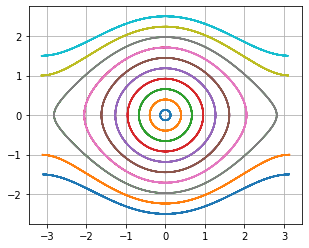

In [6]:
titf = (0,30)
t = np.linspace(titf[0],titf[-1],1000)
N_tray = 20
vth0 = np.linspace(-2.5,2.5,N_tray)
for i in range(N_tray):
    ci = [0,vth0[i]]
    sol_pendulo = si.solve_ivp(pendulo,titf,ci,rtol=1e-8,atol=1e-10,dense_output=True)
    th_vth = sol_pendulo.sol(t)
    if vth0[i] > 2:
        th_p = (th_vth[0] + np.pi)%(2*np.pi) - np.pi
        th_p[:-1][ np.diff( th_p) <0 ] = np.nan
        plt.plot(th_p,th_vth[1])
    elif vth0[i] < -2:
        th_p = (th_vth[0] + np.pi)%(2*np.pi) - np.pi
        th_p[:-1][ np.diff( th_p) > 0 ] = np.nan
        plt.plot(th_p,th_vth[1])
    else:
        plt.plot(th_vth[0],th_vth[1])
plt.gca().set_aspect('equal')
plt.grid()
plt.show()

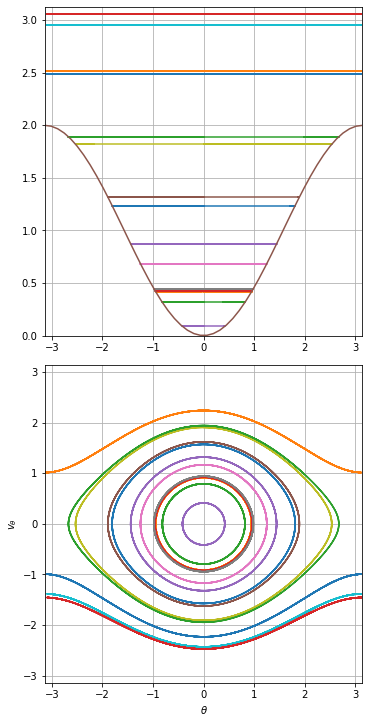

In [90]:
titf = (0,30)
t = np.linspace(titf[0],titf[-1],1000)
N_tray , v_max = 15 , 2.5
vth0=[]
fig , ejes = plt.subplots(2,1,figsize=(5,10),layout="constrained",)
for i in range(N_tray):
    vth0.append(rd.uniform(-v_max,v_max))
for i in range(N_tray):
    ci = [0,vth0[i]]
    sol_pendulo = si.solve_ivp(pendulo,titf,ci,rtol=1e-8,atol=1e-10,dense_output=True)
    th_vth = sol_pendulo.sol(t)
    Ener = E_pendulo(th_vth)
    if abs(vth0[i]) > 2:
        th_p = (th_vth[0] + np.pi)%(2*np.pi) - np.pi
        th_p[:-1][ abs(np.diff( th_p)) > 0.5 ] = np.nan
        ejes[1].plot(th_p,th_vth[1])
        ejes[0].plot(th_p,Ener)
    else:
        ejes[1].plot(th_vth[0],th_vth[1])
        ejes[0].plot(th_vth[0],Ener)
th_esp = np.linspace(-np.pi,np.pi)
V_pot = 1 - np.cos(th_esp)
ejes[0].plot(th_esp,V_pot)
ejes[0].sharex(ejes[1])
ejes[1].set_aspect('equal')
ejes[1].set_xlabel(r'${\theta}$'),ejes[1].set_ylabel(r'$v_{\theta}$')
ejes[1].set_xlim([-np.pi,np.pi]),ejes[1].set_ylim([-np.pi,np.pi])
ejes[0].set_xlim([-np.pi,np.pi]),ejes[0].set_ylim([0,0.5*v_max**2])
ejes[0].grid(),ejes[1].grid()
plt.show()

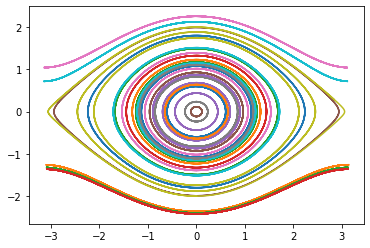

In [134]:
titf = (0,30)
t = np.linspace(titf[0],titf[-1],1000)
N_tray , v_max = 30 , 2.5
vth0=[]
for i in range(N_tray):
    vth0.append(rd.uniform(-2.5,2.5))
datos = np.zeros((len(t),3,N_tray)) # th,vth,E
for i in range(N_tray):
    ci = [0,vth0[i]]
    sol_pendulo = si.solve_ivp(pendulo,titf,ci,rtol=1e-8,atol=1e-10,dense_output=True)
    th_vth = sol_pendulo.sol(t)
    Ener = E_pendulo(th_vth)
    if abs(vth0[i]) > 2:
        th_p = (th_vth[0] + np.pi)%(2*np.pi) - np.pi
        th_p[:-1][ abs(np.diff( th_p)) > 0.5 ] = np.nan
        datos[:,0,i] = th_p
        datos[:,1,i] = th_vth[1]
        datos[:,2,i] = Ener
    else:
        datos[:,0:2,i] = th_vth.transpose()
        datos[:,2,i] = Ener
for p in range(N_tray):
    plt.plot(datos[:,0,p],datos[:,1,p])

In [135]:
fig , ejes = plt.subplots(2,1,figsize=(5,10),layout="constrained",)
#
part_ener, = ejes[0].plot([],[],'o')
#
part, = ejes[1].plot([],[],'o')
lineas, lineas_ener = [] , []
for i in range(N_tray):
    lineas_ener.append( ejes[0].plot([],[])[0] )
    lineas.append( ejes[1].plot([],[])[0] )
th_esp = np.linspace(-np.pi,np.pi)
V_pot = 1 - np.cos(th_esp)
ejes[0].plot(th_esp,V_pot)
#ejes[0].sharex(ejes[1])
ejes[1].set_aspect('equal')
ejes[0].set_ylabel(r'$E$')
ejes[1].set_xlabel(r'${\theta}$'),ejes[1].set_ylabel(r'$v_{\theta}$')
ejes[1].set_xlim([-np.pi,np.pi]),ejes[1].set_ylim([-np.pi,np.pi])
ejes[0].set_xlim([-np.pi,np.pi]),ejes[0].set_ylim([0,0.5*v_max**2])
ejes[0].grid(),ejes[1].grid()
#

def cuadro(ti):
    # graficas energia
    part_ener.set_data(datos[ti,0,:],datos[ti,2,:])
    # graficas espacio fase
    part.set_data(datos[ti,0,:],datos[ti,1,:])
    for i in range(N_tray):
        lineas_ener[i].set_data(datos[:ti,0,i],datos[:ti,2,i])
        lineas[i].set_data(datos[:ti,0,i],datos[:ti,1,i])
    return part,part_ener,

animacion = FuncAnimation(fig,cuadro,frames=len(t), interval = 41,blit=False)

plt.close()
HTML(animacion.to_html5_video()) # Usar esta linea si tengo compresor de video
#HTML(animacion.to_jshtml()) # Usar esta linea si NO tengo compresor de video